
## Exercise 13 — Simulated Linear Regression

- **(a–c)** Generate $X \sim N(0,1)$, $\varepsilon \sim N(0, 0.25)$, compute $Y$.
- **(d–f)** Fit OLS, compare $\hat{\beta}_0, \hat{\beta}_1$ to true values, plot.
- **(g)** Test whether adding $X^2$ improves the fit.
- **(h–i)** Repeat with lower/higher noise variance.
- **(j)** Compare confidence intervals across noise levels.


In [1]:

import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                        summarize ,
                        poly)

In [2]:

rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(scale=np.sqrt(0.25),size=100)
y = -1. + 0.5*x + eps

Text(0, 0.5, 'y')

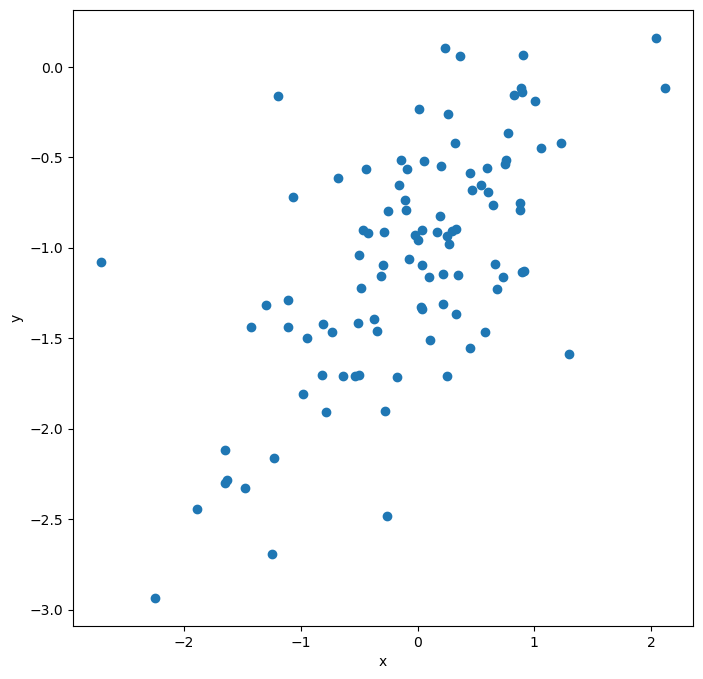

In [3]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x,y)
ax.set_xlabel('x')
ax.set_ylabel('y')


In [4]:
df = pd.DataFrame({'x':x, 'y':y})
X = MS(['x']).fit_transform(df)
model1 = sm.OLS(y,X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,-1.0380,0.050,-20.647,0.0
x,0.4843,0.059,8.233,0.0


/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_88826/4094492484.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results1.params[0],
/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_88826/4094492484.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results1.params[1],


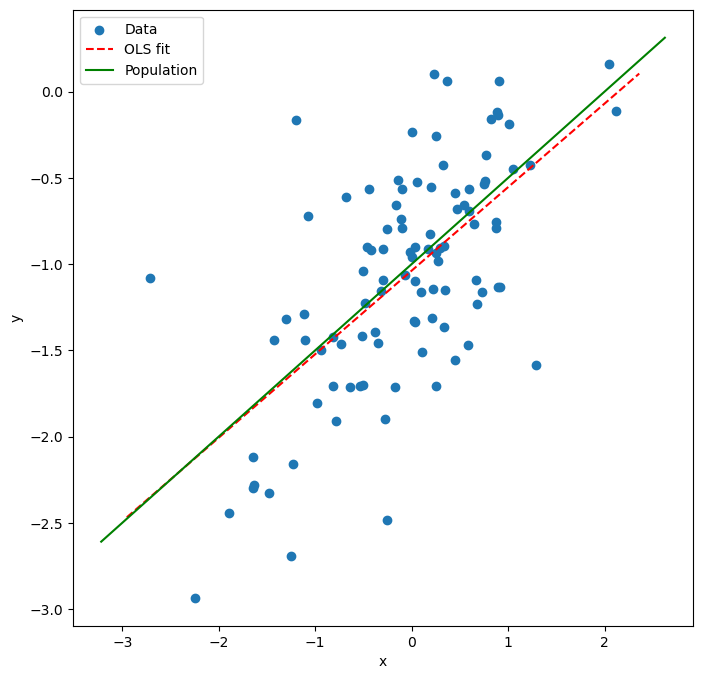

In [5]:
from cProfile import label


def abline(ax,b,m,*args,**kwargs):
    xlim = ax.get_xlim()
    ylim = [xlim[0]*m + b,xlim[1]*m +b]
    ax.plot(xlim,ylim,*args,**kwargs)

ax = subplots(figsize=(8,8))[1]
ax.scatter(x,y,label='Data')
ax.set_xlabel('x')
ax.set_ylabel('y')
abline(ax,
        results1.params[0],
        results1.params[1],
        c='r',
        ls='--',
        label='OLS fit')
# True population line: y = -1 + 0.5x
abline(ax, -1, 0.5,
       c='g', ls='-', label='Population')
       
ax.legend()

In [6]:
X2 = MS([poly('x', degree=2, raw=True)]).fit_transform(df)
model2 = sm.OLS(y, X2)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,-1.0364,0.060,-17.399,0.000
"poly(x, degree=2, raw=True)[0]",0.4831,0.063,7.647,0.000
"poly(x, degree=2, raw=True)[1]",-0.0024,0.045,-0.052,0.959


We observe a p-value $\approx$ 0.96 for $x^2$, so we can't reject $H_o : \beta_{x^2}=0$.

### Test: reduced noise in $\epsilon$

In [7]:
eps = rng.normal(scale=0.02,size=100) # reduced variance 
y = -1. + 0.5*x + eps
df = pd.DataFrame({'x':x, 'y':y})
X = MS(['x']).fit_transform(df)
model3 = sm.OLS(y,X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,-1.0032,0.002,-541.853,0.0
x,0.4997,0.002,230.704,0.0


### Test: increased noise in $x$

In [8]:

eps = rng.normal(scale=2,size=100) # reduced variance 
y = -1. + 0.5*x + eps
df = pd.DataFrame({'x':x, 'y':y})
X = MS(['x']).fit_transform(df)
model4 = sm.OLS(y,X)
results4 = model4.fit()
summarize(results4)

,coef,std err,t,P>|t|
intercept,-1.0183,0.175,-5.822,0.0
x,0.7940,0.205,3.880,0.0


### Confidence intervals for the three models 

In [10]:
print('model1 confidence interval: {0}'.format(results1.conf_int(alpha=0.05)))
print('model3 confidence interval: {0}'.format(results3.conf_int(alpha=0.05)))
print('model4 confidence interval: {0}'.format(results4.conf_int(alpha=0.05)))

model1 confidence interval:                   0         1
intercept -1.137782 -0.938244
x          0.367565  0.601017
model3 confidence interval:                   0         1
intercept -1.006913 -0.999564
x          0.495446  0.504043
model4 confidence interval:                   0         1
intercept -1.365422 -0.671214
x          0.387892  1.200085
